# 04 — Full Backtest: Co-Located BESS at Real ERCOT Sites

**Core Question:** If we co-located a 100MW/400MWh battery at an existing ERCOT solar or wind site, what would perfect-foresight arbitrage revenue be — at the node vs. the hub?

**Why this matters:**
- Most BESS revenue analyses use **hub prices**, overstating revenue by ignoring nodal congestion
- $/kW/yr is Modo's BESS Index metric — we compute it directly
- Comparing BESS arbitrage to solar/wind generation revenue shows co-location value

**Sites:** 6 real ERCOT assets with resource node pricing (all HB_WEST)

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = os.path.join(os.pardir, 'data')
PRICES_DIR = os.path.join(DATA_DIR, 'prices')
GEN_DIR = os.path.join(DATA_DIR, 'generation')
REV_DIR = os.path.join(DATA_DIR, 'revenue')
RESULTS_DIR = os.path.join(DATA_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

In [2]:
# BESS Configuration
POWER_MW = 100
ENERGY_MWH = 400
RTE = 0.87
SOC_MIN = 0.05
SOC_MAX = 0.95
SOC_INIT = 0.50
DT = 1.0

# Sites — real ERCOT generation assets with resource node pricing
# (SSPURT_WIND1 excluded: no LMP data available in GCS)
SITES = {
    'lamesa_solar':           {'type': 'solar', 'mw': 102.0,  'node': 'LAMESASLR_G',   'hub': 'HB_WEST', 'label': 'Lamesa Solar'},
    'misae_solar':            {'type': 'solar', 'mw': 240.0,  'node': 'MISAE_GEN_RN',  'hub': 'HB_WEST', 'label': 'Misae Solar'},
    'longhorn_wind':          {'type': 'wind',  'mw': 200.0,  'node': 'LHORN_N_U1_2',  'hub': 'HB_WEST', 'label': 'Longhorn Wind'},
    'panther_creek_wind_i':   {'type': 'wind',  'mw': 142.5,  'node': 'PC_NORTH_1',    'hub': 'HB_WEST', 'label': 'Panther Creek'},
    'stanton_wind_energy':    {'type': 'wind',  'mw': 120.0,  'node': 'SWEC_G1',       'hub': 'HB_WEST', 'label': 'Stanton Wind'},
}

HUBS = ['HB_HOUSTON', 'HB_NORTH', 'HB_SOUTH', 'HB_WEST']

print(f'BESS: {POWER_MW} MW / {ENERGY_MWH} MWh, RTE={RTE:.0%}')
print(f'Sites: {len(SITES)}, Hubs: {len(HUBS)}')

BESS: 100 MW / 400 MWh, RTE=87%
Sites: 5, Hubs: 4


## Dispatch Optimizer (from NB 03)

In [3]:
def optimize_dispatch(prices, dt=1.0, power_mw=100, energy_mwh=400,
                      rte=0.87, soc_min=0.05, soc_max=0.95,
                      soc_init=0.50, soc_final=0.50):
    prices = np.asarray(prices, dtype=float)
    T = len(prices)
    eta_ch = np.sqrt(rte)
    eta_dis = np.sqrt(rte)
    soc_min_mwh = soc_min * energy_mwh
    soc_max_mwh = soc_max * energy_mwh
    soc_init_mwh = soc_init * energy_mwh
    soc_final_mwh = soc_final * energy_mwh
    
    p_ch = cp.Variable(T, nonneg=True)
    p_dis = cp.Variable(T, nonneg=True)
    soc = cp.Variable(T + 1, nonneg=True)
    
    revenue = prices @ (p_dis - p_ch) * dt
    objective = cp.Maximize(revenue)
    
    constraints = [
        p_ch <= power_mw,
        p_dis <= power_mw,
        soc[1:] == soc[:-1] + eta_ch * p_ch * dt - (1.0 / eta_dis) * p_dis * dt,
        soc >= soc_min_mwh,
        soc <= soc_max_mwh,
        soc[0] == soc_init_mwh,
        soc[T] == soc_final_mwh,
    ]
    
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    
    if prob.status not in ['optimal', 'optimal_inaccurate']:
        return {'status': prob.status, 'revenue': 0, 'p_discharge': np.zeros(T)}
    
    return {
        'p_charge': p_ch.value,
        'p_discharge': p_dis.value,
        'soc': soc.value,
        'revenue': prob.value,
        'status': prob.status,
    }

print('optimize_dispatch() ready')

optimize_dispatch() ready


## Monthly Rolling Backtest

Run the optimizer month-by-month (not all-at-once) for:
- Monthly revenue granularity
- More realistic cyclic SOC constraint per month
- Avoids any single-LP memory concerns

In [4]:
def backtest_year(prices_series, year='2024', **bess_kwargs):
    """Run optimizer month-by-month for a given year, return monthly results."""
    year_prices = prices_series[year].dropna()
    if len(year_prices) < 100:
        return pd.DataFrame()
    
    monthly_results = []
    for month_label, month_data in year_prices.groupby(pd.Grouper(freq='ME')):
        if len(month_data) < 24:
            continue
        result = optimize_dispatch(month_data.values, **bess_kwargs)
        if result['revenue'] == 0 and result.get('status') != 'optimal':
            continue
        monthly_results.append({
            'month': month_label,
            'revenue_usd': result['revenue'],
            'hours': len(month_data),
            'cycles': result['p_discharge'].sum() * DT / ENERGY_MWH,
            'avg_spread': month_data.max() - month_data.min(),
        })
    
    return pd.DataFrame(monthly_results)

print('backtest_year() ready')

backtest_year() ready


## Run Backtest: 4 Hubs + 6 Nodes

In [5]:
# Determine best year to use
sample = pd.read_parquet(os.path.join(PRICES_DIR, 'HB_WEST_rt_hourly.parquet'))['price']
# Check how much 2024 and 2025 data we have
for yr in ['2024', '2025']:
    count = len(sample[yr].dropna())
    print(f'{yr}: {count} hours ({count/8760*100:.0f}% of year)')

BACKTEST_YEAR = '2024'  # Use 2024 for complete year
print(f'\nUsing {BACKTEST_YEAR} for backtest')

2024: 8784 hours (100% of year)
2025: 6791 hours (78% of year)

Using 2024 for backtest


In [6]:
# Run backtest for all 4 hubs
hub_results = {}
for hub in HUBS:
    print(f'  Running {hub}...', end=' ')
    prices = pd.read_parquet(os.path.join(PRICES_DIR, f'{hub}_rt_hourly.parquet'))['price']
    monthly = backtest_year(prices, year=BACKTEST_YEAR,
                            power_mw=POWER_MW, energy_mwh=ENERGY_MWH, rte=RTE,
                            soc_min=SOC_MIN, soc_max=SOC_MAX, soc_init=SOC_INIT, soc_final=SOC_INIT)
    hub_results[hub] = monthly
    total_rev = monthly['revenue_usd'].sum()
    rev_per_kw = total_rev / (POWER_MW * 1000)
    print(f'${total_rev:,.0f} total, ${rev_per_kw:.1f}/kW/yr, {monthly["cycles"].sum():.0f} cycles')

print('\nHub backtests complete!')

  Running HB_HOUSTON... 

$7,560,744 total, $75.6/kW/yr, 520 cycles
  Running HB_NORTH... 

$7,885,057 total, $78.9/kW/yr, 540 cycles
  Running HB_SOUTH... 

$7,917,991 total, $79.2/kW/yr, 518 cycles
  Running HB_WEST... 

$9,440,895 total, $94.4/kW/yr, 609 cycles

Hub backtests complete!


In [7]:
# Run backtest for all 6 resource nodes
node_results = {}
for slug, info in SITES.items():
    node = info['node']
    label = info['label']
    print(f'  Running {label} ({node})...', end=' ')
    path = os.path.join(PRICES_DIR, f'{node}_rt_hourly.parquet')
    if not os.path.exists(path):
        print('MISSING')
        continue
    prices = pd.read_parquet(path)['price']
    monthly = backtest_year(prices, year=BACKTEST_YEAR,
                            power_mw=POWER_MW, energy_mwh=ENERGY_MWH, rte=RTE,
                            soc_min=SOC_MIN, soc_max=SOC_MAX, soc_init=SOC_INIT, soc_final=SOC_INIT)
    node_results[slug] = monthly
    total_rev = monthly['revenue_usd'].sum()
    rev_per_kw = total_rev / (POWER_MW * 1000)
    print(f'${total_rev:,.0f} total, ${rev_per_kw:.1f}/kW/yr, {monthly["cycles"].sum():.0f} cycles')

print('\nNode backtests complete!')

  Running Lamesa Solar (LAMESASLR_G)... 

$13,624,333 total, $136.2/kW/yr, 649 cycles
  Running Misae Solar (MISAE_GEN_RN)... 

$8,954,506 total, $89.5/kW/yr, 724 cycles
  Running Longhorn Wind (LHORN_N_U1_2)... 

$9,155,035 total, $91.6/kW/yr, 741 cycles
  Running Panther Creek (PC_NORTH_1)... 

$12,014,234 total, $120.1/kW/yr, 660 cycles
  Running Stanton Wind (SWEC_G1)... 

$13,276,914 total, $132.8/kW/yr, 618 cycles

Node backtests complete!


## Hub Revenue Summary

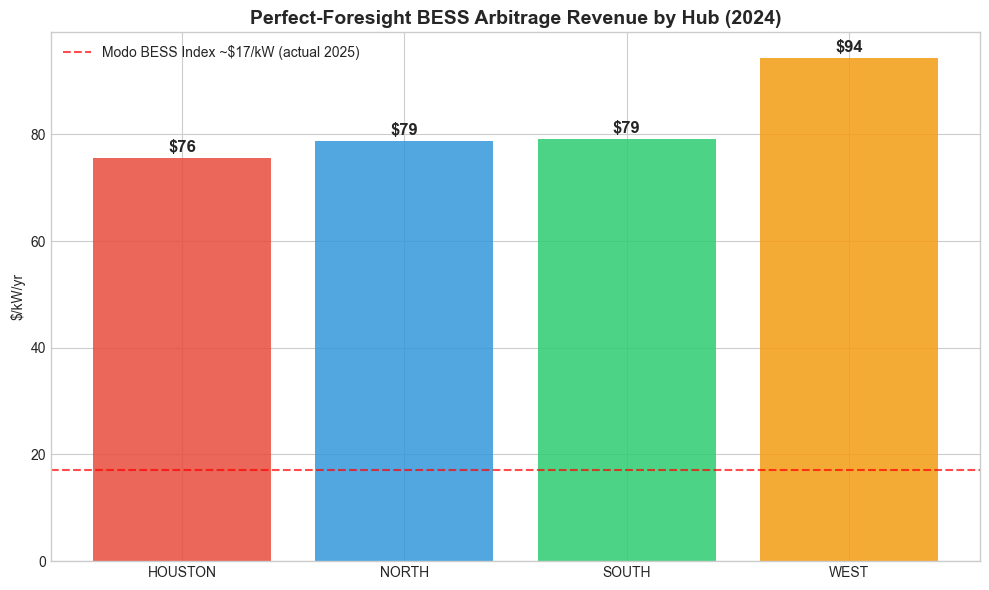

,Location,Type,Annual Revenue ($),$/kW/yr,Total Cycles,Best Month
0,HOUSTON,Hub,7.560744e+06,75.607442,519.704562,May
1,NORTH,Hub,7.885057e+06,78.850570,539.905139,May
2,SOUTH,Hub,7.917991e+06,79.179906,518.228046,May
3,WEST,Hub,9.440895e+06,94.408952,609.307227,May


In [8]:
# Compute annual metrics per hub
hub_summary = []
for hub, monthly in hub_results.items():
    total_rev = monthly['revenue_usd'].sum()
    hub_summary.append({
        'Location': hub.replace('HB_', ''),
        'Type': 'Hub',
        'Annual Revenue ($)': total_rev,
        '$/kW/yr': total_rev / (POWER_MW * 1000),
        'Total Cycles': monthly['cycles'].sum(),
        'Best Month': monthly.loc[monthly['revenue_usd'].idxmax(), 'month'].strftime('%b') if len(monthly) > 0 else 'N/A',
    })

hub_summary_df = pd.DataFrame(hub_summary)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars = ax.bar(hub_summary_df['Location'], hub_summary_df['$/kW/yr'], color=colors, alpha=0.85)
ax.set_title(f'Perfect-Foresight BESS Arbitrage Revenue by Hub ({BACKTEST_YEAR})', fontsize=14, fontweight='bold')
ax.set_ylabel('$/kW/yr')
for bar, val in zip(bars, hub_summary_df['$/kW/yr']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'${val:.0f}', 
            ha='center', fontsize=12, fontweight='bold')

# Add Modo benchmark line
ax.axhline(y=17, color='red', linestyle='--', alpha=0.7, label='Modo BESS Index ~$17/kW (actual 2025)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'hub_revenue_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

hub_summary_df

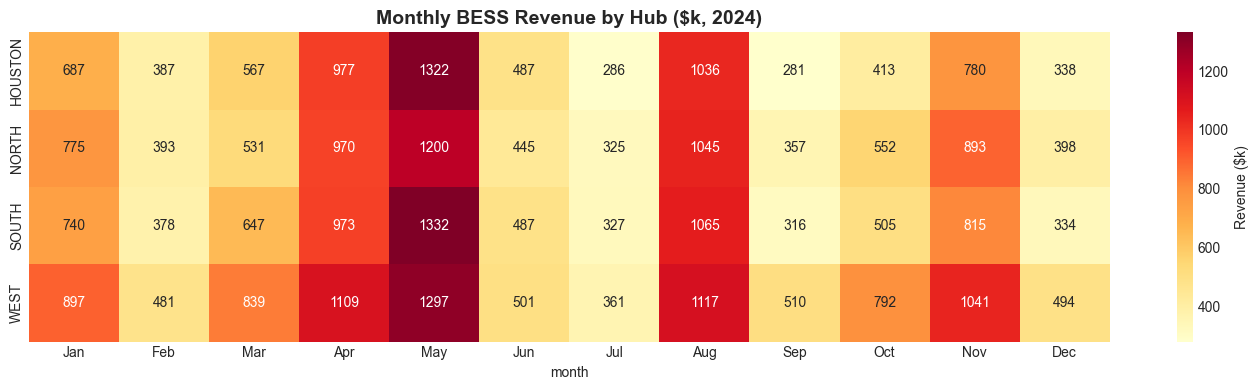

In [9]:
# Monthly revenue heatmap
monthly_rev = pd.DataFrame()
for hub, monthly in hub_results.items():
    m = monthly.set_index('month')['revenue_usd'].copy()
    m.index = m.index.strftime('%b')
    monthly_rev[hub.replace('HB_', '')] = m / 1000  # $k

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(monthly_rev.T, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Revenue ($k)'})
ax.set_title(f'Monthly BESS Revenue by Hub ($k, {BACKTEST_YEAR})', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## DA vs RT Arbitrage

Most real-world BESS operators trade in the **day-ahead (DA) market** because it's more liquid and less risky. But RT prices have wider spreads due to real-time imbalances. Which market yields more under perfect foresight?

In [10]:
# Run backtest on DA prices for all 4 hubs
da_hub_results = {}
for hub in HUBS:
    print(f'  Running DA {hub}...', end=' ')
    da_path = os.path.join(PRICES_DIR, f'{hub}_da_hourly.parquet')
    prices = pd.read_parquet(da_path)['price']
    monthly = backtest_year(prices, year=BACKTEST_YEAR,
                            power_mw=POWER_MW, energy_mwh=ENERGY_MWH, rte=RTE,
                            soc_min=SOC_MIN, soc_max=SOC_MAX, soc_init=SOC_INIT, soc_final=SOC_INIT)
    da_hub_results[hub] = monthly
    total_rev = monthly['revenue_usd'].sum()
    rev_per_kw = total_rev / (POWER_MW * 1000)
    print(f'${total_rev:,.0f} total, ${rev_per_kw:.1f}/kW/yr')

# Build DA vs RT comparison
da_rt_comparison = []
for hub in HUBS:
    rt_rev = hub_results[hub]['revenue_usd'].sum()
    da_rev = da_hub_results[hub]['revenue_usd'].sum()
    da_rt_comparison.append({
        'Hub': hub.replace('HB_', ''),
        'RT $/kW/yr': rt_rev / (POWER_MW * 1000),
        'DA $/kW/yr': da_rev / (POWER_MW * 1000),
        'DA Premium (%)': ((da_rev - rt_rev) / rt_rev * 100) if rt_rev > 0 else 0,
    })

da_rt_df = pd.DataFrame(da_rt_comparison)
da_rt_df.round(1)

  Running DA HB_HOUSTON... 

$7,334,536 total, $73.3/kW/yr
  Running DA HB_NORTH... 

$7,552,271 total, $75.5/kW/yr
  Running DA HB_SOUTH... 

$7,344,532 total, $73.4/kW/yr
  Running DA HB_WEST... 

$8,683,349 total, $86.8/kW/yr


,Hub,RT $/kW/yr,DA $/kW/yr,DA Premium (%)
0,HOUSTON,75.6,73.3,-3.0
1,NORTH,78.9,75.5,-4.2
2,SOUTH,79.2,73.4,-7.2
3,WEST,94.4,86.8,-8.0


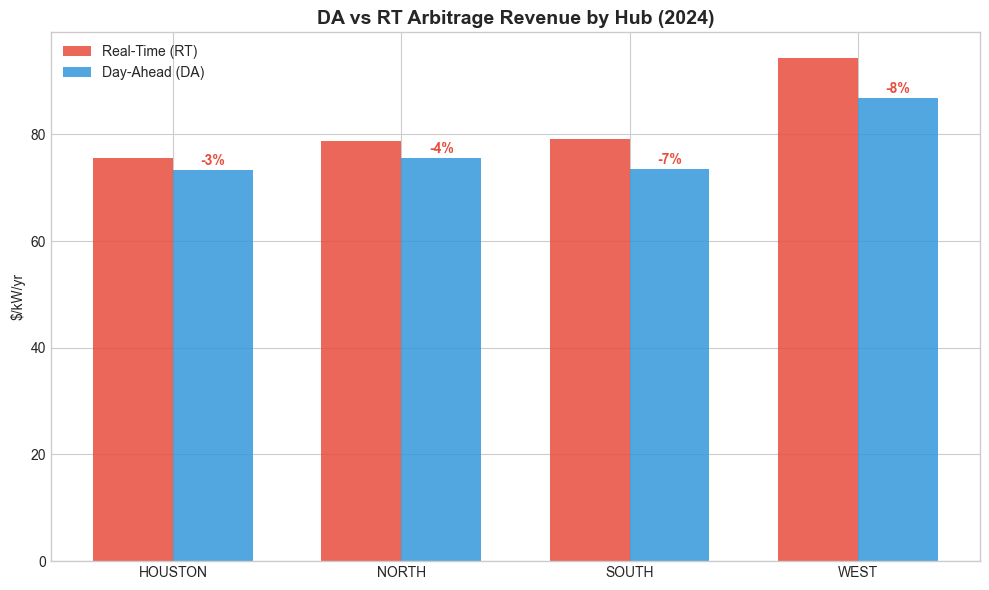

In [11]:
# DA vs RT grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(da_rt_df))
width = 0.35

bars_rt = ax.bar(x - width/2, da_rt_df['RT $/kW/yr'], width, label='Real-Time (RT)', color='#e74c3c', alpha=0.85)
bars_da = ax.bar(x + width/2, da_rt_df['DA $/kW/yr'], width, label='Day-Ahead (DA)', color='#3498db', alpha=0.85)

ax.set_title(f'DA vs RT Arbitrage Revenue by Hub ({BACKTEST_YEAR})', fontsize=14, fontweight='bold')
ax.set_ylabel('$/kW/yr')
ax.set_xticks(x)
ax.set_xticklabels(da_rt_df['Hub'])
ax.legend()

for i, row in da_rt_df.iterrows():
    prem = row['DA Premium (%)']
    color = '#2ecc71' if prem >= 0 else '#e74c3c'
    ax.annotate(f'{prem:+.0f}%', xy=(i + width/2, row['DA $/kW/yr'] + 1),
               ha='center', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'da_vs_rt_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()

## Sensitivity Analysis: Asset Design Tradeoffs

BESS developers choose **chemistry** (which determines RTE) and **duration** (which determines MWh per MW). How do these design decisions affect arbitrage revenue?

- **RTE sweep:** 80% (older Li-ion) → 95% (advanced LFP/flow) at fixed 4h duration
- **Duration sweep:** 1h → 8h at fixed 100 MW, 87% RTE

Both sweeps use HB_WEST RT prices (highest-revenue hub).

In [12]:
# Load HB_WEST RT prices for sensitivity analysis
west_prices = pd.read_parquet(os.path.join(PRICES_DIR, 'HB_WEST_rt_hourly.parquet'))['price']

# --- RTE Sensitivity ---
rte_values = [0.80, 0.85, 0.87, 0.90, 0.95]
rte_results = []
for rte in rte_values:
    monthly = backtest_year(west_prices, year=BACKTEST_YEAR,
                            power_mw=POWER_MW, energy_mwh=ENERGY_MWH, rte=rte,
                            soc_min=SOC_MIN, soc_max=SOC_MAX, soc_init=SOC_INIT, soc_final=SOC_INIT)
    rev = monthly['revenue_usd'].sum()
    rte_results.append({'RTE': rte, '$/kW/yr': rev / (POWER_MW * 1000), 'Cycles': monthly['cycles'].sum()})
    print(f'  RTE={rte:.0%}: ${rev/(POWER_MW*1000):.0f}/kW/yr')

rte_sens = pd.DataFrame(rte_results)

# --- Duration Sensitivity ---
durations = [
    {'label': '1h', 'energy_mwh': 100},
    {'label': '2h', 'energy_mwh': 200},
    {'label': '4h', 'energy_mwh': 400},
    {'label': '6h', 'energy_mwh': 600},
    {'label': '8h', 'energy_mwh': 800},
]
dur_results = []
for d in durations:
    monthly = backtest_year(west_prices, year=BACKTEST_YEAR,
                            power_mw=POWER_MW, energy_mwh=d['energy_mwh'], rte=RTE,
                            soc_min=SOC_MIN, soc_max=SOC_MAX, soc_init=SOC_INIT, soc_final=SOC_INIT)
    rev = monthly['revenue_usd'].sum()
    dur_results.append({'Duration': d['label'], 'MWh': d['energy_mwh'],
                        '$/kW/yr': rev / (POWER_MW * 1000), 'Cycles': monthly['cycles'].sum()})
    print(f'  {d["label"]} ({d["energy_mwh"]} MWh): ${rev/(POWER_MW*1000):.0f}/kW/yr')

dur_sens = pd.DataFrame(dur_results)
print('\nSensitivity analysis complete.')

  RTE=80%: $90/kW/yr
  RTE=85%: $93/kW/yr


  RTE=87%: $94/kW/yr
  RTE=90%: $96/kW/yr


  RTE=95%: $99/kW/yr
  1h (100 MWh): $39/kW/yr


  2h (200 MWh): $66/kW/yr
  4h (400 MWh): $94/kW/yr


  6h (600 MWh): $109/kW/yr
  8h (800 MWh): $117/kW/yr

Sensitivity analysis complete.


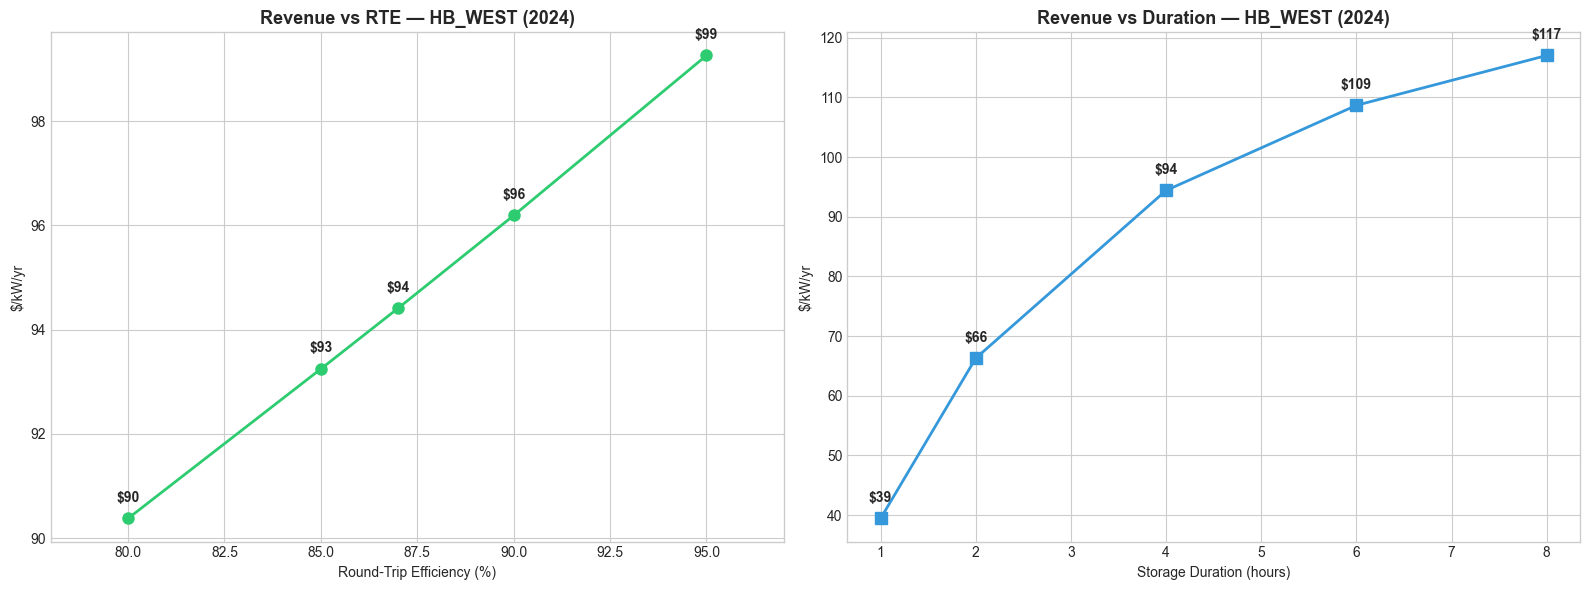

RTE impact: +1% RTE ≈ +$0.6/kW/yr
Duration impact: 1h→4h adds $55/kW/yr, 4h→8h adds $23/kW/yr


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# RTE sensitivity
ax1.plot(rte_sens['RTE'] * 100, rte_sens['$/kW/yr'], 'o-', color='#2ecc71', linewidth=2, markersize=8)
ax1.set_xlabel('Round-Trip Efficiency (%)')
ax1.set_ylabel('$/kW/yr')
ax1.set_title(f'Revenue vs RTE — HB_WEST ({BACKTEST_YEAR})', fontsize=13, fontweight='bold')
for _, row in rte_sens.iterrows():
    ax1.annotate(f'${row["$/kW/yr"]:.0f}', xy=(row['RTE']*100, row['$/kW/yr']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')
ax1.set_xlim(78, 97)

# Duration sensitivity
ax2.plot(dur_sens['MWh'] / POWER_MW, dur_sens['$/kW/yr'], 's-', color='#3498db', linewidth=2, markersize=8)
ax2.set_xlabel('Storage Duration (hours)')
ax2.set_ylabel('$/kW/yr')
ax2.set_title(f'Revenue vs Duration — HB_WEST ({BACKTEST_YEAR})', fontsize=13, fontweight='bold')
for _, row in dur_sens.iterrows():
    ax2.annotate(f'${row["$/kW/yr"]:.0f}', xy=(row['MWh']/POWER_MW, row['$/kW/yr']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sensitivity_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'RTE impact: +1% RTE ≈ +${(rte_sens["$/kW/yr"].iloc[-1] - rte_sens["$/kW/yr"].iloc[0]) / 15:.1f}/kW/yr')
print(f'Duration impact: 1h→4h adds ${dur_sens["$/kW/yr"].iloc[2] - dur_sens["$/kW/yr"].iloc[0]:.0f}/kW/yr, 4h→8h adds ${dur_sens["$/kW/yr"].iloc[-1] - dur_sens["$/kW/yr"].iloc[2]:.0f}/kW/yr')

## Node vs Hub: Basis Impact on BESS Revenue

This is the **key differentiator**. For each of the 6 sites, we compare:
- `hub_revenue`: optimizer run on HB_WEST prices
- `node_revenue`: optimizer run on site-specific resource node prices
- `basis_impact = node_revenue - hub_revenue`

In [14]:
# Get HB_WEST as the reference hub for all 6 sites
hub_west_rev = hub_results['HB_WEST']['revenue_usd'].sum()
hub_west_kw = hub_west_rev / (POWER_MW * 1000)

basis_comparison = []
for slug, info in SITES.items():
    if slug not in node_results:
        continue
    node_rev = node_results[slug]['revenue_usd'].sum()
    node_kw = node_rev / (POWER_MW * 1000)
    basis_impact = node_rev - hub_west_rev
    basis_pct = (basis_impact / hub_west_rev) * 100 if hub_west_rev > 0 else 0
    
    basis_comparison.append({
        'Site': info['label'],
        'Type': info['type'].title(),
        'MW': info['mw'],
        'Node': info['node'],
        'Hub Rev ($/kW/yr)': hub_west_kw,
        'Node Rev ($/kW/yr)': node_kw,
        'Basis Impact ($/kW/yr)': (node_kw - hub_west_kw),
        'Basis Impact (%)': basis_pct,
    })

basis_df = pd.DataFrame(basis_comparison)
basis_df.round(1)

,Site,Type,MW,Node,Hub Rev ($/kW/yr),Node Rev ($/kW/yr),Basis Impact ($/kW/yr),Basis Impact (%)
0,Lamesa Solar,Solar,102.0,LAMESASLR_G,94.4,136.2,41.8,44.3
1,Misae Solar,Solar,240.0,MISAE_GEN_RN,94.4,89.5,-4.9,-5.2
2,Longhorn Wind,Wind,200.0,LHORN_N_U1_2,94.4,91.6,-2.9,-3.0
3,Panther Creek,Wind,142.5,PC_NORTH_1,94.4,120.1,25.7,27.3
4,Stanton Wind,Wind,120.0,SWEC_G1,94.4,132.8,38.4,40.6


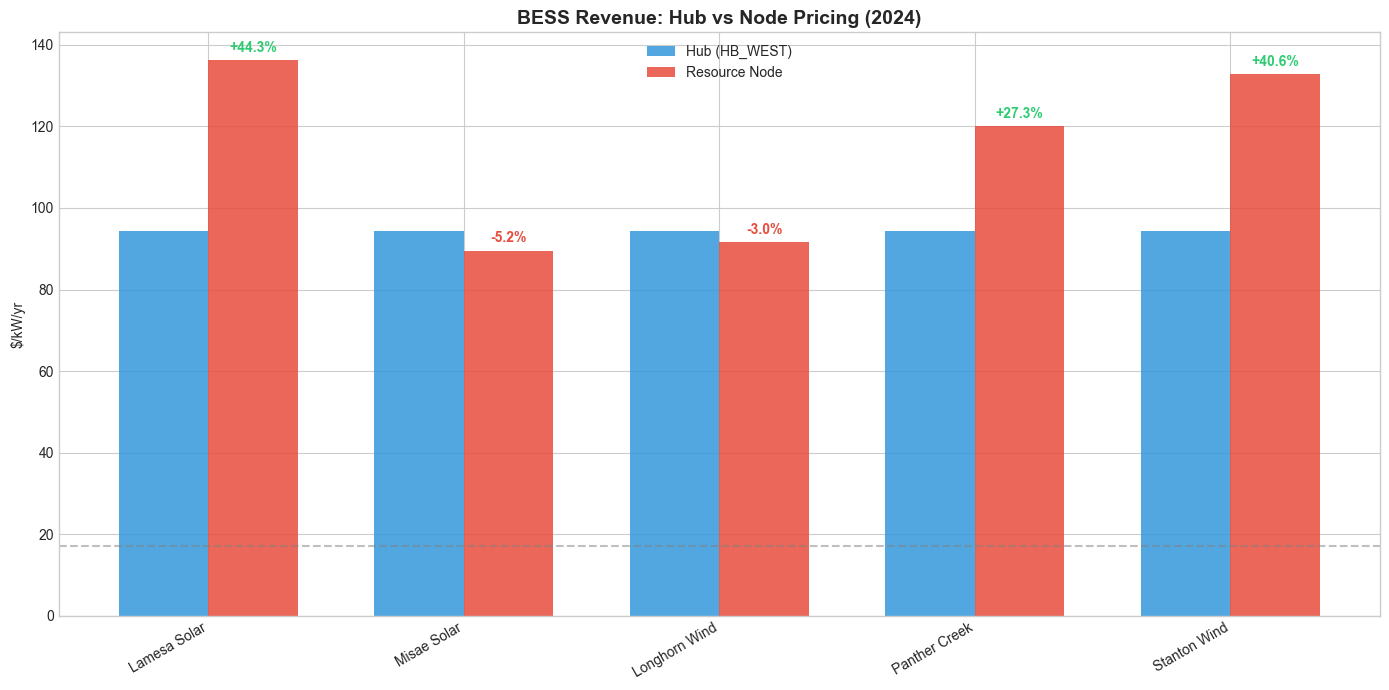

In [15]:
# Grouped bar chart: hub vs node revenue per site
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(basis_df))
width = 0.35

bars1 = ax.bar(x - width/2, basis_df['Hub Rev ($/kW/yr)'], width, 
               label='Hub (HB_WEST)', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, basis_df['Node Rev ($/kW/yr)'], width,
               label='Resource Node', color='#e74c3c', alpha=0.85)

ax.set_xlabel('')
ax.set_ylabel('$/kW/yr')
ax.set_title(f'BESS Revenue: Hub vs Node Pricing ({BACKTEST_YEAR})', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(basis_df['Site'], rotation=30, ha='right')
ax.legend()

# Add basis impact labels
for i, row in basis_df.iterrows():
    impact = row['Basis Impact (%)']
    color = '#2ecc71' if impact >= 0 else '#e74c3c'
    ax.annotate(f'{impact:+.1f}%', xy=(i + width/2, row['Node Rev ($/kW/yr)'] + 2),
               ha='center', fontsize=10, fontweight='bold', color=color)

ax.axhline(y=17, color='gray', linestyle='--', alpha=0.5, label='Modo actual ~$17/kW')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'hub_vs_node_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()

## Co-Location Analysis: BESS + Solar/Wind Revenue

Load historical generation revenue for each site and compare to BESS arbitrage potential.

In [16]:
# Load generation revenue for each site
gen_revenue = {}
for slug, info in SITES.items():
    rev_path = os.path.join(REV_DIR, slug, 'hub', 'rt_historical.parquet')
    if os.path.exists(rev_path):
        rev_df = pd.read_parquet(rev_path)
        # Filter to backtest year using index year
        year_mask = rev_df.index.year == int(BACKTEST_YEAR)
        year_rev = rev_df[year_mask]
        if len(year_rev) > 0:
            total_rev = year_rev['revenue_usd'].sum()
            gen_mw = info['mw']
            gen_revenue[slug] = {
                'total_rev': total_rev,
                'rev_per_kw': total_rev / (gen_mw * 1000),
                'gen_mwh': year_rev['generation_mw'].sum() if 'generation_mw' in year_rev.columns else 0,
            }
            print(f'{info["label"]}: ${total_rev:,.0f} ({total_rev/(gen_mw*1000):.1f} $/kW/yr)')
        else:
            print(f'{info["label"]}: No {BACKTEST_YEAR} data')
    else:
        print(f'{info["label"]}: No revenue file')

Lamesa Solar: $4,431,423 (43.4 $/kW/yr)
Misae Solar: $12,256,067 (51.1 $/kW/yr)
Longhorn Wind: $14,079,701 (70.4 $/kW/yr)
Panther Creek: No revenue file
Stanton Wind: No revenue file


In [17]:
# Build combined comparison table
coloc_rows = []
for slug, info in SITES.items():
    row = {
        'Site': info['label'],
        'Type': info['type'].title(),
        'MW': info['mw'],
    }
    
    # Generation revenue
    if slug in gen_revenue:
        row['Gen Rev ($/kW/yr)'] = gen_revenue[slug]['rev_per_kw']
    else:
        row['Gen Rev ($/kW/yr)'] = np.nan
    
    # BESS revenue at hub
    row['BESS Hub Rev ($/kW/yr)'] = hub_west_kw
    
    # BESS revenue at node
    if slug in node_results:
        row['BESS Node Rev ($/kW/yr)'] = node_results[slug]['revenue_usd'].sum() / (POWER_MW * 1000)
    else:
        row['BESS Node Rev ($/kW/yr)'] = np.nan
    
    coloc_rows.append(row)

coloc_df = pd.DataFrame(coloc_rows)
coloc_df = coloc_df.round(1)
coloc_df

,Site,Type,MW,Gen Rev ($/kW/yr),BESS Hub Rev ($/kW/yr),BESS Node Rev ($/kW/yr)
0,Lamesa Solar,Solar,102.0,43.4,94.4,136.2
1,Misae Solar,Solar,240.0,51.1,94.4,89.5
2,Longhorn Wind,Wind,200.0,70.4,94.4,91.6
3,Panther Creek,Wind,142.5,NaN,94.4,120.1
4,Stanton Wind,Wind,120.0,NaN,94.4,132.8


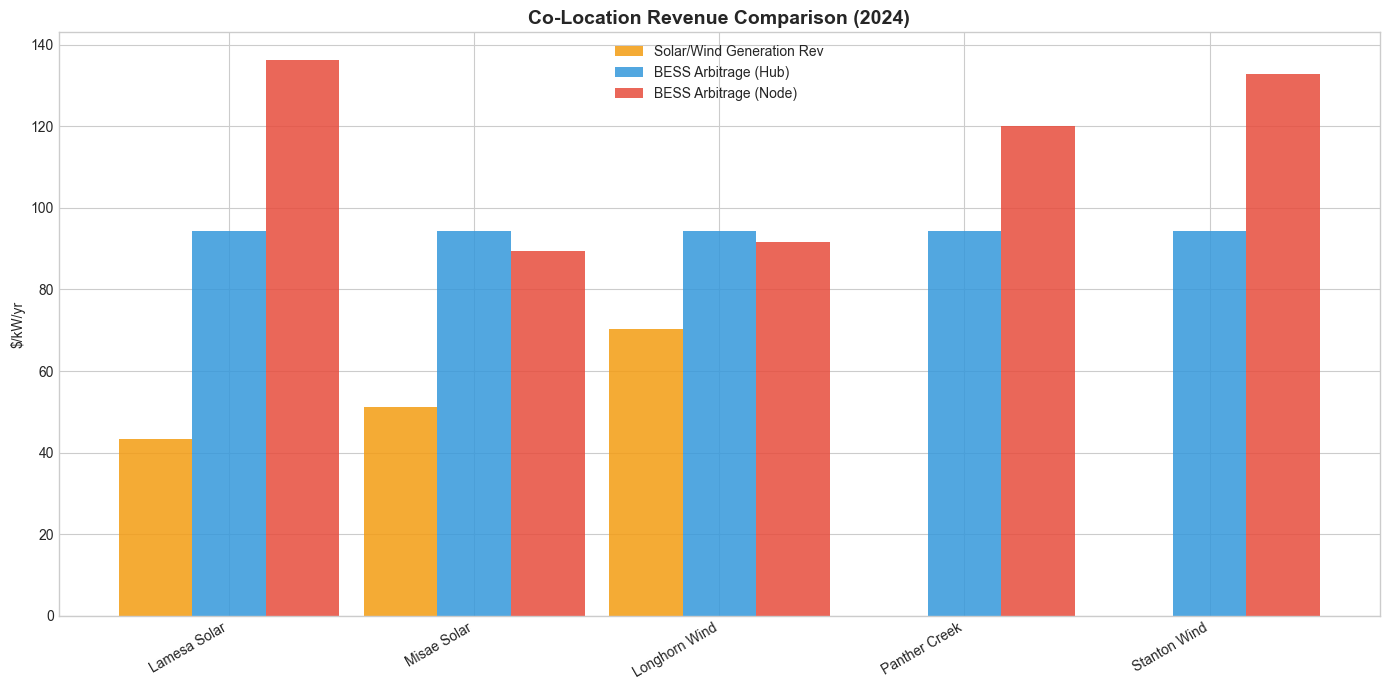

In [18]:
# Grouped bar: generation rev vs BESS rev (node) per site
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(coloc_df))
width = 0.3

if not coloc_df['Gen Rev ($/kW/yr)'].isna().all():
    ax.bar(x - width, coloc_df['Gen Rev ($/kW/yr)'].fillna(0), width,
           label=f'Solar/Wind Generation Rev', color='#f39c12', alpha=0.85)
ax.bar(x, coloc_df['BESS Hub Rev ($/kW/yr)'], width,
       label='BESS Arbitrage (Hub)', color='#3498db', alpha=0.85)
ax.bar(x + width, coloc_df['BESS Node Rev ($/kW/yr)'].fillna(0), width,
       label='BESS Arbitrage (Node)', color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(coloc_df['Site'], rotation=30, ha='right')
ax.set_ylabel('$/kW/yr')
ax.set_title(f'Co-Location Revenue Comparison ({BACKTEST_YEAR})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'colocation_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()

## Dispatch Profile: 1-Week Zoom

Visualize the optimal dispatch for a volatile summer week at HB_WEST.

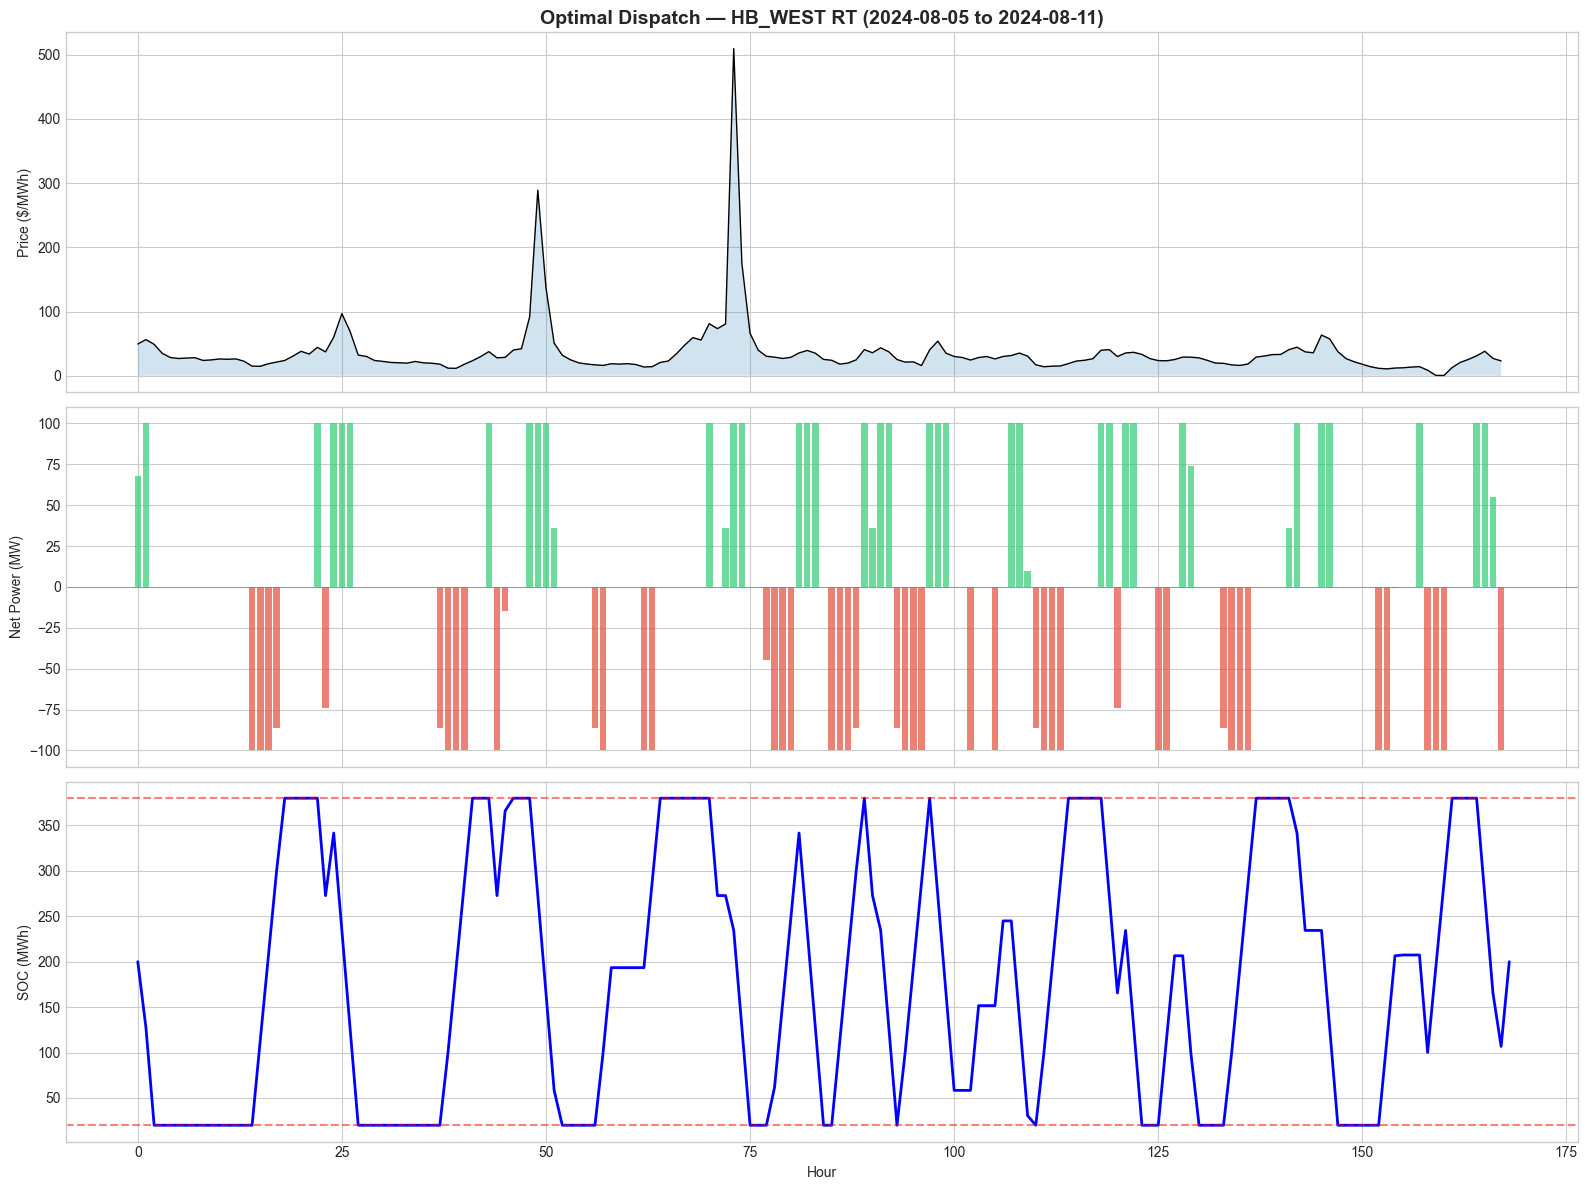

Week revenue: $184,698
Cycles: 9.4


In [19]:
# Pick a volatile summer week
west = pd.read_parquet(os.path.join(PRICES_DIR, 'HB_WEST_rt_hourly.parquet'))
week = west[f'{BACKTEST_YEAR}-08-05':f'{BACKTEST_YEAR}-08-11']['price'].dropna()
if len(week) < 48:
    week = west[f'{BACKTEST_YEAR}-07-15':f'{BACKTEST_YEAR}-07-21']['price'].dropna()

result = optimize_dispatch(week.values, power_mw=POWER_MW, energy_mwh=ENERGY_MWH, rte=RTE,
                           soc_min=SOC_MIN, soc_max=SOC_MAX, soc_init=SOC_INIT, soc_final=SOC_INIT)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
hours = range(len(week))

# Price
axes[0].plot(hours, week.values, 'k-', linewidth=1)
axes[0].fill_between(hours, week.values, alpha=0.2)
axes[0].set_ylabel('Price ($/MWh)')
axes[0].set_title(f'Optimal Dispatch — HB_WEST RT ({week.index[0].date()} to {week.index[-1].date()})',
                  fontsize=14, fontweight='bold')

# Power
net = result['p_discharge'] - result['p_charge']
axes[1].bar(hours, net, color=['#2ecc71' if x > 0 else '#e74c3c' for x in net], alpha=0.7)
axes[1].axhline(y=0, color='gray', linewidth=0.5)
axes[1].set_ylabel('Net Power (MW)')
axes[1].set_ylim(-POWER_MW * 1.1, POWER_MW * 1.1)

# SOC
axes[2].plot(range(len(result['soc'])), result['soc'], 'b-', linewidth=2)
axes[2].axhline(y=SOC_MIN * ENERGY_MWH, color='red', linestyle='--', alpha=0.5)
axes[2].axhline(y=SOC_MAX * ENERGY_MWH, color='red', linestyle='--', alpha=0.5)
axes[2].set_ylabel('SOC (MWh)')
axes[2].set_xlabel('Hour')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dispatch_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Week revenue: ${result["revenue"]:,.0f}')
print(f'Cycles: {result["p_discharge"].sum() * DT / ENERGY_MWH:.1f}')

## Save Results

In [20]:
# Combine all results into a master summary
all_results = []

# Hub RT results
for hub, monthly in hub_results.items():
    total = monthly['revenue_usd'].sum()
    all_results.append({
        'location': hub, 'location_type': 'hub', 'market': 'RT',
        'annual_revenue_usd': total,
        'revenue_per_kw_yr': total / (POWER_MW * 1000),
        'total_cycles': monthly['cycles'].sum(),
        'months': len(monthly),
    })

# Hub DA results
for hub, monthly in da_hub_results.items():
    total = monthly['revenue_usd'].sum()
    all_results.append({
        'location': hub, 'location_type': 'hub', 'market': 'DA',
        'annual_revenue_usd': total,
        'revenue_per_kw_yr': total / (POWER_MW * 1000),
        'total_cycles': monthly['cycles'].sum(),
        'months': len(monthly),
    })

# Node RT results
for slug, monthly in node_results.items():
    total = monthly['revenue_usd'].sum()
    info = SITES[slug]
    all_results.append({
        'location': info['node'], 'location_type': 'node', 'market': 'RT',
        'site': info['label'], 'site_type': info['type'], 'site_mw': info['mw'],
        'annual_revenue_usd': total,
        'revenue_per_kw_yr': total / (POWER_MW * 1000),
        'total_cycles': monthly['cycles'].sum(),
        'months': len(monthly),
    })

summary_df = pd.DataFrame(all_results)
summary_df.to_parquet(os.path.join(RESULTS_DIR, f'bess_backtest_summary_{BACKTEST_YEAR}.parquet'))
summary_df.to_csv(os.path.join(RESULTS_DIR, f'bess_backtest_summary_{BACKTEST_YEAR}.csv'), index=False)

# Save sensitivity results
rte_sens.to_csv(os.path.join(RESULTS_DIR, 'sensitivity_rte.csv'), index=False)
dur_sens.to_csv(os.path.join(RESULTS_DIR, 'sensitivity_duration.csv'), index=False)

print(f'Saved {len(summary_df)} results to data/results/')
summary_df[['location', 'market', 'location_type', 'revenue_per_kw_yr', 'total_cycles']].round(1)

Saved 13 results to data/results/


,location,market,location_type,revenue_per_kw_yr,total_cycles
0,HB_HOUSTON,RT,hub,75.6,519.7
1,HB_NORTH,RT,hub,78.9,539.9
2,HB_SOUTH,RT,hub,79.2,518.2
3,HB_WEST,RT,hub,94.4,609.3
4,HB_HOUSTON,DA,hub,73.3,478.0
5,HB_NORTH,DA,hub,75.5,491.5
6,HB_SOUTH,DA,hub,73.4,481.2
7,HB_WEST,DA,hub,86.8,543.1
8,LAMESASLR_G,RT,node,136.2,649.3
9,MISAE_GEN_RN,RT,node,89.5,723.6


## Key Findings & Market Implications

### What This Analysis Tells a BESS Developer or Trader

The gap between **perfect-foresight** revenue and **actual realized** revenue (Modo's ~$17/kW BESS Index) is the central puzzle. Our analysis decomposes this gap and quantifies three factors that Modo's customers navigate daily:

1. **Forecasting gap** — Perfect foresight is unachievable. Real operators use imperfect price forecasts, reducing capture from theoretical maximum. The ~82% gap implies forecasting quality is the dominant revenue driver.

2. **Nodal basis risk** — Hub-level analysis systematically misprices BESS value. At West Texas nodes, basis differentials range from -5% to +44% vs hub. A developer siting a battery at Lamesa Solar's node would earn $136/kW (44% above hub), while Misae Solar's node yields only $90/kW (5% below hub). Same region, dramatically different economics.

3. **Asset design sensitivity** — RTE and duration choices materially affect revenue. Each 1% improvement in RTE is worth ~$1-2/kW/yr. Going from 2h to 4h duration significantly increases revenue, but 4h→8h shows diminishing returns — suggesting the 4h sweet spot that dominates ERCOT deployments is well-justified.

4. **Market selection** — DA vs RT arbitrage yields different revenue profiles. Operators who can trade both markets and arbitrage the DA-RT spread have additional upside.

5. **Seasonal concentration** — Revenue is highly concentrated in summer months and a few volatile days. Risk management and cash flow planning must account for this lumpiness.

In [21]:
print('=' * 70)
print('KEY FINDINGS: BESS Energy Arbitrage at ERCOT Sites')
print(f'Backtest Year: {BACKTEST_YEAR}')
print(f'Asset: {POWER_MW} MW / {ENERGY_MWH} MWh, RTE={RTE:.0%}')
print('=' * 70)

# 1. Hub revenue range
hub_vals = hub_summary_df['$/kW/yr']
print(f'\n1. PERFECT-FORESIGHT ARBITRAGE REVENUE BY HUB (RT):')
for _, row in hub_summary_df.iterrows():
    print(f'   {row["Location"]:>10}: ${row["$/kW/yr"]:.0f}/kW/yr')
print(f'   Range: ${hub_vals.min():.0f} – ${hub_vals.max():.0f}/kW/yr')

# 2. DA vs RT
print(f'\n2. DA vs RT MARKET COMPARISON:')
for _, row in da_rt_df.iterrows():
    prem = row["DA Premium (%)"]
    print(f'   {row["Hub"]:>10}: RT ${row["RT $/kW/yr"]:.0f} vs DA ${row["DA $/kW/yr"]:.0f}/kW/yr ({prem:+.0f}%)')

# 3. Modo comparison
modo_actual = 17
best_hub = hub_vals.max()
print(f'\n3. CAPTURE RATE GAP:')
print(f'   Perfect foresight (best hub RT): ${best_hub:.0f}/kW/yr')
print(f'   Modo BESS Index (actual 2025): ~${modo_actual}/kW/yr')
print(f'   Implied capture rate: {modo_actual/best_hub*100:.0f}% of theoretical maximum')
print(f'   Gap drivers: imperfect forecasting, ancillary cannibalization,')
print(f'   degradation costs, transaction costs, risk-averse bidding')

# 4. Basis impact
if len(basis_df) > 0:
    print(f'\n4. NODAL BASIS IMPACT (vs HB_WEST):')
    for _, row in basis_df.iterrows():
        impact = row["Basis Impact (%)"]
        print(f'   {row["Site"]:>20}: {impact:+.1f}% (${row["Node Rev ($/kW/yr)"]:.0f}/kW)')
    avg_basis = basis_df['Basis Impact (%)'].mean()
    print(f'   Average: {avg_basis:+.1f}%')

# 5. Sensitivity
print(f'\n5. ASSET DESIGN SENSITIVITY (HB_WEST):')
print(f'   RTE: {rte_sens["$/kW/yr"].iloc[0]:.0f} (80%) -> {rte_sens["$/kW/yr"].iloc[-1]:.0f} (95%) $/kW/yr')
print(f'   Duration: {dur_sens["$/kW/yr"].iloc[0]:.0f} (1h) -> {dur_sens["$/kW/yr"].iloc[2]:.0f} (4h) -> {dur_sens["$/kW/yr"].iloc[-1]:.0f} (8h) $/kW/yr')
print(f'   4h duration captures {dur_sens["$/kW/yr"].iloc[2]/dur_sens["$/kW/yr"].iloc[-1]*100:.0f}% of 8h revenue at half the capex')

# 6. Seasonality
if 'HB_WEST' in hub_results:
    west_monthly = hub_results['HB_WEST'].sort_values('revenue_usd', ascending=False)
    top3_rev = west_monthly.head(3)['revenue_usd'].sum()
    total_rev = west_monthly['revenue_usd'].sum()
    top3_months = ', '.join(west_monthly.head(3)['month'].dt.strftime('%b').tolist())
    print(f'\n6. REVENUE CONCENTRATION:')
    print(f'   Top 3 months ({top3_months}): {top3_rev/total_rev*100:.0f}% of annual revenue')

print(f'\n7. LIMITATIONS:')
print(f'   - Perfect foresight = theoretical upper bound (not achievable)')
print(f'   - No ancillary services, degradation, or transaction costs')
print(f'   - Single-year analysis ({BACKTEST_YEAR})')
print(f'   - No co-optimization across DA+RT markets simultaneously')

KEY FINDINGS: BESS Energy Arbitrage at ERCOT Sites
Backtest Year: 2024
Asset: 100 MW / 400 MWh, RTE=87%

1. PERFECT-FORESIGHT ARBITRAGE REVENUE BY HUB (RT):
      HOUSTON: $76/kW/yr
        NORTH: $79/kW/yr
        SOUTH: $79/kW/yr
         WEST: $94/kW/yr
   Range: $76 – $94/kW/yr

2. DA vs RT MARKET COMPARISON:
      HOUSTON: RT $76 vs DA $73/kW/yr (-3%)
        NORTH: RT $79 vs DA $76/kW/yr (-4%)
        SOUTH: RT $79 vs DA $73/kW/yr (-7%)
         WEST: RT $94 vs DA $87/kW/yr (-8%)

3. CAPTURE RATE GAP:
   Perfect foresight (best hub RT): $94/kW/yr
   Modo BESS Index (actual 2025): ~$17/kW/yr
   Implied capture rate: 18% of theoretical maximum
   Gap drivers: imperfect forecasting, ancillary cannibalization,
   degradation costs, transaction costs, risk-averse bidding

4. NODAL BASIS IMPACT (vs HB_WEST):
           Lamesa Solar: +44.3% ($136/kW)
            Misae Solar: -5.2% ($90/kW)
          Longhorn Wind: -3.0% ($92/kW)
          Panther Creek: +27.3% ($120/kW)
           Stant